# Credit Card Fraud Detection
#### By: Claire Newsom and Macy Moore

## Question and Background Information

## Exploratory Data Analysis

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve,
    average_precision_score
)


In [2]:
# Load Data
df = pd.read_csv("creditcard.csv")
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum().sum()} total")
print(f"\nClass distribution:\n{df['Class'].value_counts()}")
print(f"\nFraud prevalence: {df['Class'].mean()*100:.3f}%")
print("\nGeneral Information:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

Shape: (284807, 31)

Missing values:
0 total

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud prevalence: 0.173%

General Information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17

### The Data Is Highly Imbalanced

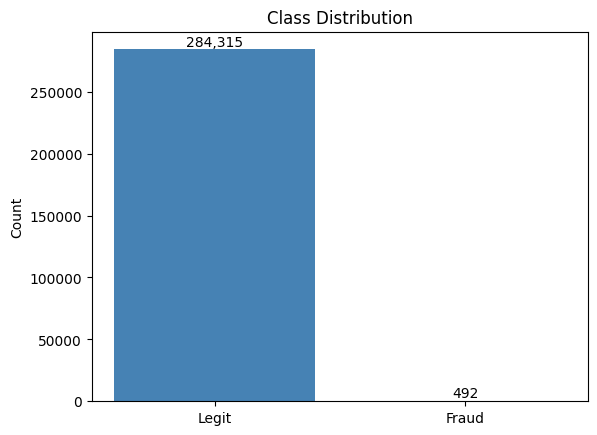

Extreme Imbalance: 99.83% legitimate vs 0.17% fraud.


In [3]:
#Class imbalance bar chart
counts = df["Class"].value_counts()
total = counts.sum()
plt.bar(["Legit","Fraud"], counts, color=["steelblue", "tomato"])
plt.title("Class Distribution")
plt.ylabel("Count")

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha = "center", va = "bottom")

plt.show()

legit_pct = counts[0] / total * 100
fraud_pct = counts[1] / total * 100

print(f"Extreme Imbalance: {legit_pct:.2f}% legitimate vs {fraud_pct:.2f}% fraud.")

### Amount is right-skewed, and fraud transactions cluster at lower amounts.

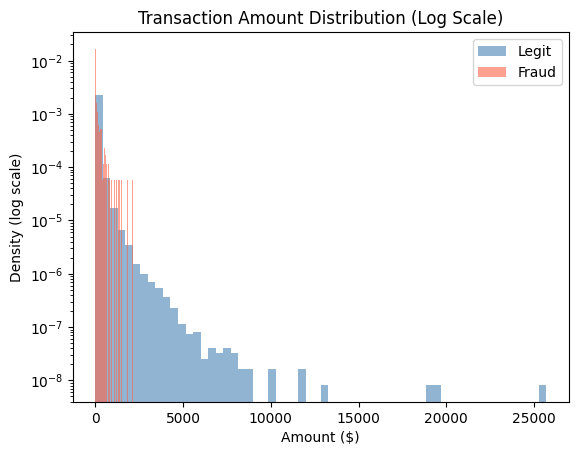

/tmp/ipykernel_9322/779347060.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y="Amount", palette=["steelblue", "tomato"])


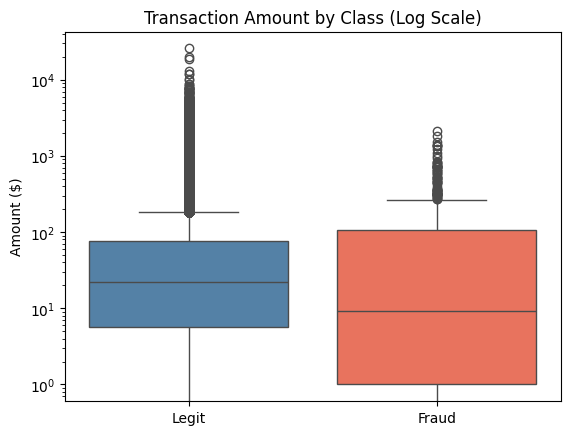

Median fraud = $9.25 vs legit = $22.00.
Fraud transactions tend to be smaller amounts.
Amount is skwed right.


In [4]:
#Compute medians
median_legit = df[df["Class"] == 0]["Amount"].median()
median_fraud = df[df["Class"] == 1]["Amount"].median()

#Histogram by Class
# Split data by class
legit = df[df["Class"] == 0]["Amount"]  
fraud = df[df["Class"] == 1]["Amount"]  

# Plot overlapping histograms
plt.hist(legit, bins=60, alpha=0.6, label="Legit", color="steelblue", density=True)
plt.hist(fraud, bins=60, alpha=0.6, label="Fraud", color="tomato", density=True)

# Use log scale on y-axis to compress large differences in counts and make rare fraud distribution visible
plt.yscale("log")
plt.xlabel("Amount ($)")
plt.ylabel("Density (log scale)")
plt.title("Transaction Amount Distribution (Log Scale)")
plt.legend()

plt.show()

#Box plot - use log scale because it is skewed
sns.boxplot(data=df, x="Class", y="Amount", palette=["steelblue", "tomato"])
plt.yscale("log")

plt.xticks([0, 1], ["Legit", "Fraud"])
plt.title("Transaction Amount by Class (Log Scale)")
plt.xlabel("")
plt.ylabel("Amount ($)")

plt.show()

print(f"Median fraud = ${median_fraud:.2f} vs legit = ${median_legit:.2f}.")
print("Fraud transactions tend to be smaller amounts.")
print("Amount is skwed right.")

### PCA features V3, V14, V17, and V12 show the strongest separation between classes.

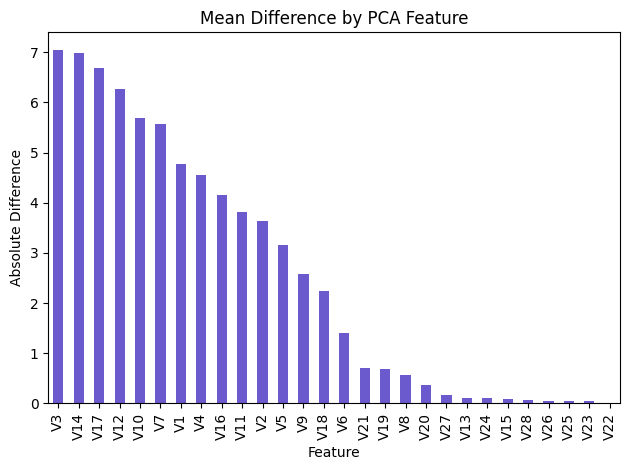

Features with strongest separation: V3, V14, V17, V12.


In [5]:
# Split dataset into fraud and legit
fraud = df[df["Class"] == 1]
legit = df[df["Class"] == 0]

# Select PCA feature columns (V1 to V28)
pca_cols = [f"V{i}" for i in range(1, 29)]

# Compute absolute difference in mean between fraud and legit for each feature
diff = (fraud[pca_cols].mean() - legit[pca_cols].mean()).abs()

# Sort features by importance (highest difference first)
diff = diff.sort_values(ascending=False)

# Plot bar chart
diff.plot(kind="bar", color="slateblue")

plt.title("Mean Difference by PCA Feature")
plt.ylabel("Absolute Difference")
plt.xlabel("Feature")

plt.tight_layout()
plt.show()

# Show top features driving separation
top_features = diff.head(4).index.tolist()
print(f"Features with strongest separation: {', '.join(top_features)}.")

## Models

### Model 1: Logistic Regression Baseline

### Data Preparation

In [6]:
X = df.drop(columns=["Class"])
y = df["Class"].astype(int)

# Log-transform Amount to reduce right skew
X["Amount"] = np.log1p(X["Amount"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")
print(f"Train fraud rate: {y_train.mean()*100:.3f}%")
print(f"Test  fraud rate: {y_test.mean()*100:.3f}%")

Train size: 227,845  |  Test size: 56,962
Train fraud rate: 0.173%
Test  fraud rate: 0.172%


### Model 1a: Logistic Regression Baseline

In [7]:
# Pipeline:
# 1) Scale features
# 2) Train logistic regression balanced class weights
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight = "balanced", max_iter=1000, random_state=42))
])

# Train model
pipe_lr.fit(X_train, y_train)

# Predictions
y_pred = pipe_lr.predict(X_test)
y_prob = pipe_lr.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistic Regression Results")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))

print("\nTakeaway (default):")
print("- High recall but very low precision for fraud")
print("- Model flags too many transactions as fraud")
print("- Not practical for real-world use")

Logistic Regression Results
[[55461  1403]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9711170870993304
PR-AUC : 0.7113138893265318

Takeaway (default):
- High recall but very low precision for fraud
- Model flags too many transactions as fraud
- Not practical for real-world use


### Model 1b: Logistic Regression Baseline with Threshold Tuning

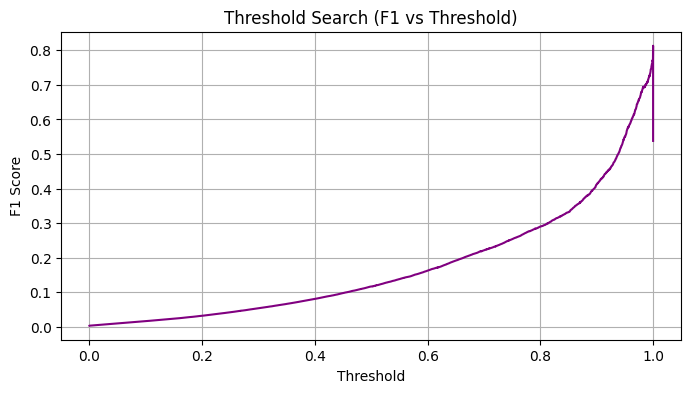

Best threshold: 1.000


In [8]:
# Get probabilities from training set
y_prob_train = pipe_lr.predict_proba(X_train)[:, 1]

# Precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_train, y_prob_train)

# Compute F1 score for each threshold
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)

# Plot F1 vs threshold
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1, color="purple")

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Search (F1 vs Threshold)")
plt.grid(True)

plt.show()

# Best threshold
best_idx = np.argmax(f1)
best_thresh = thresholds[best_idx]

print(f"Best threshold: {best_thresh:.3f}")

In [9]:
# Apply new threshold to test set
y_pred_tuned = (y_prob >= best_thresh).astype(int)

# Evaluation again
print("\nTuned Logistic Regression Results")
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))

print("\nTakeaway (tuned):")
print("- Huge improvement in precision for fraud detection")
print("- Much fewer false alarms")
print("- Better balance between catching fraud and accuracy")
print("- More realistic for production use")


Tuned Logistic Regression Results
[[56848    16]
 [   18    80]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9711170870993304
PR-AUC : 0.7113138893265318

Takeaway (tuned):
- Huge improvement in precision for fraud detection
- Much fewer false alarms
- Better balance between catching fraud and accuracy
- More realistic for production use


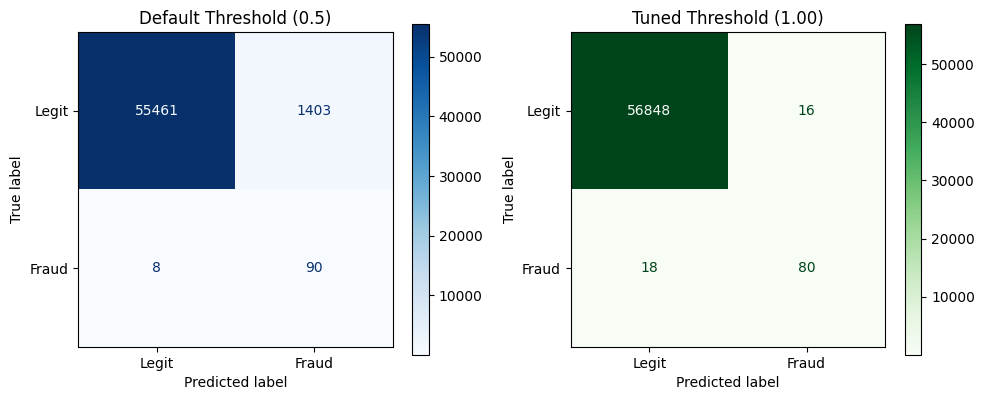

In [10]:
#Visual Comparison of Confusion matrices for models 1a and 1b
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Legit", "Fraud"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Default Threshold (0.5)")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=["Legit", "Fraud"],
    cmap="Greens",
    ax=axes[1]
)
axes[1].set_title(f"Tuned Threshold ({best_thresh:.2f})")

plt.tight_layout()
plt.show()

### Model 2: Logistic Regression Oversampling

### Resampling

In [11]:
from sklearn.utils import resample
import pandas as pd

fraud = df[df["Class"] == 1]
legit = df[df["Class"] == 0]

target_fraction = 0.50

n_legit = len(legit)
n_fraud_needed = int((target_fraction * n_legit) / (1 - target_fraction))

fraud_upsampled = resample(
    fraud,
    replace=True,
    n_samples=n_fraud_needed,
    random_state=42
)

df_balanced = pd.concat([legit, fraud_upsampled]).sample(frac=1, random_state=42)

print(df_balanced["Class"].value_counts(normalize=True))

X = df_balanced.drop("Class", axis=1)
y = df_balanced["Class"]

# Log-transform Amount to reduce right skew
X["Amount"] = np.log1p(X["Amount"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Class
1    0.5
0    0.5
Name: proportion, dtype: float64


### Model 2a: Logistic Regression Oversampling Baseline

In [14]:
model2 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

model2.fit(X_train, y_train)

y_prob_2 = model2.predict_proba(X_test)[:, 1]
y_pred_2 = model2.predict(X_test)

print("\nOversampled Logistic Regression)")
print(confusion_matrix(y_test, y_pred_2))
print(classification_report(y_test, y_pred_2))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_2))
print("PR-AUC :", average_precision_score(y_test, y_prob_2))


Oversampled Logistic Regression)
[[55644  1219]
 [ 4624 52239]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     56863
           1       0.98      0.92      0.95     56863

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726

ROC-AUC: 0.9866114422266966
PR-AUC : 0.9890800259101022


### Model 2b: Logistic Regression Oversampling and Threshold Tuning

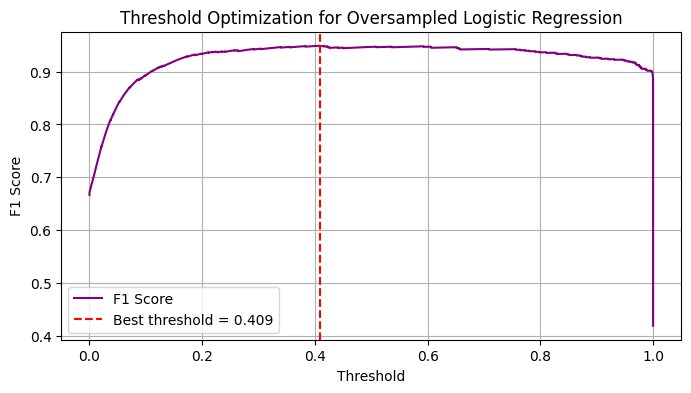

Best threshold: 0.409


In [23]:
# Probabilities from Model 3 (same model used in Model 4)
y_prob_2b_train = model2.predict_proba(X_train)[:, 1]

# Precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_train, y_prob_2b_train)

# F1 score at each threshold
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)

# Best threshold
best_idx = np.argmax(f1)
best_thresh = thresholds[best_idx]

# Plot F1 vs threshold
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1, color="purple", label="F1 Score")

# Highlight best threshold
plt.axvline(best_thresh, color="red", linestyle="--",
            label=f"Best threshold = {best_thresh:.3f}")

plt.title("Threshold Optimization for Oversampled Logistic Regression")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)

plt.show()

print(f"Best threshold: {best_thresh:.3f}")

In [24]:
y_prob_2b_train = model2.predict_proba(X_train)[:, 1]
y_prob_2b_test  = model2.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, y_prob_2_train)

f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)

best_idx = np.argmax(f1)
best_thresh_2 = thresholds[best_idx]

y_pred_2b = (y_prob_2b_test >= best_thresh_2).astype(int)

print("\nTuned Threshold Oversampled Logistic Regression")
print(confusion_matrix(y_test, y_pred_2b))
print(classification_report(y_test, y_pred_2b))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_2b_test))
print("PR-AUC :", average_precision_score(y_test, y_prob_2b_test))


Tuned Threshold Oversampled Logistic Regression
[[55071  1792]
 [ 3798 53065]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     56863
           1       0.97      0.93      0.95     56863

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726

ROC-AUC: 0.9866114422266966
PR-AUC : 0.9890800259101022


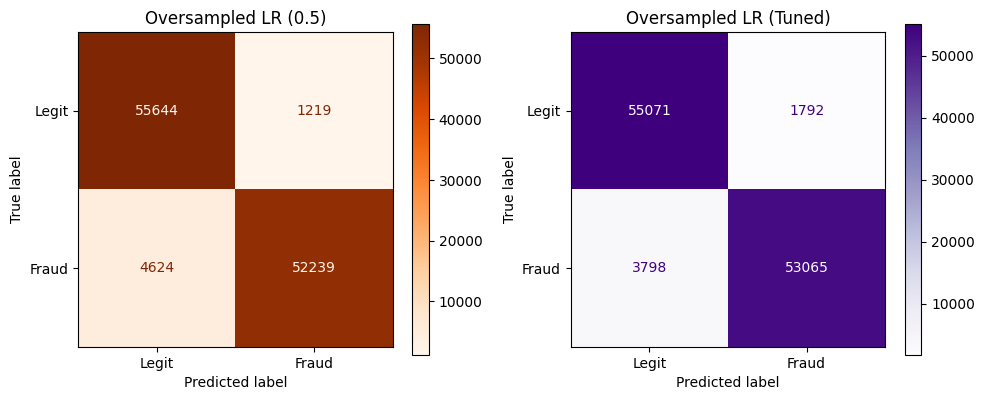

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ─────────────────────────────
# Model 2: Oversampled LR (default threshold)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_2,
    display_labels=["Legit", "Fraud"],
    cmap="Oranges",
    ax=axes[0]
)
axes[0].set_title("Oversampled LR (0.5)")

# ─────────────────────────────
# Model 4: Oversampled LR (tuned threshold)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_2b,
    display_labels=["Legit", "Fraud"],
    cmap="Purples",
    ax=axes[1]
)
axes[1].set_title("Oversampled LR (Tuned)")

plt.tight_layout()
plt.show()

## Model Evaluation

### Logistic

### Decision Trees

## Conclusion

## Team Contribution